# Scene Graph Generation & Failure Summarization Pipeline

**Tim**

This notebook runs the full REFLECT pipeline on the real-world robot data: MDETR object detection, CLIP state classification, 3D scene graph construction from RGB-D, hierarchical summarization, and GPT-4 failure reasoning. A single toggle controls whether audio events are included. The pipeline code expects a specific directory layout with hardcoded paths — the setup cells below bridge between our actual data location and what the code needs.

### Dataset & Background

The data lives at `/home/coder/datasets/real_data/`. Each task (e.g., `putAppleBowl1`, `appleInFridge1`) is a folder containing a `videos/color.mp4` video and a `replay_buffer.zarr` directory with robot metadata (action stages, gripper positions). Task definitions — object lists, actions, success conditions, ground-truth failure annotations — are in `tasks_real_world.json`.

The goal: detect *where* and *why* a robot manipulation task failed by building three levels of abstraction:
- **L0** — dense per-frame local scene graphs with spatial edges (on top of, inside, near, etc.)
- **L1** — key-frame summaries combining actions + visual scene text + optional audio
- **L2** — subgoal-level summaries (one per interaction endpoint)

These feed into GPT-4 prompts for hierarchical failure analysis.

#### References
- [REFLECT: Summarizing Robot Experiences for Failure Explanation and Correction](https://github.com/real-stanford/reflect)
- [MDETR: Modulated Detection for End-to-End Multi-Modal Understanding](https://arxiv.org/abs/2104.12763)

In [1]:
# Standard library
import os
import sys
import json
import pickle
import random
from pathlib import Path
from argparse import Namespace

# Numerical / vision
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torch
import zarr

np.random.seed(91)
random.seed(91)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda:0


### Path Configuration

The original pipeline scripts hardcode paths like `real_world/data/{task}/...` and `real_world/state_summary/{task}/...` everywhere. Rather than patching every file, we create symlinks from the expected layout to our actual data. This keeps the original modules importable without modification.

In [2]:
# ──────────────────────────────────────────────
# Actual data location
# ──────────────────────────────────────────────
DATA_DIR       = Path("/home/coder/datasets")
REAL_DATA_DIR  = DATA_DIR / "real_data"
TASK_JSON_PATH = DATA_DIR / "tasks_real_world.json"

# ──────────────────────────────────────────────
# Working / output directory
# ──────────────────────────────────────────────
WORK_DIR = Path(".").resolve()  # where the pipeline scripts live

# Create the symlink structure the pipeline code expects
rw_root = WORK_DIR / "real_world"
rw_root.mkdir(exist_ok=True)

# real_world/data  →  /home/coder/datasets/real_data
data_link = rw_root / "data"
if not data_link.exists():
    data_link.symlink_to(REAL_DATA_DIR)
    print(f"Symlinked {data_link} → {REAL_DATA_DIR}")
else:
    print(f"Link exists: {data_link} → {data_link.resolve()}")

# real_world/tasks_real_world.json
task_json_link = rw_root / "tasks_real_world.json"
if not task_json_link.exists():
    task_json_link.symlink_to(TASK_JSON_PATH)

# Output directories the pipeline writes to
(rw_root / "state_summary").mkdir(exist_ok=True)
(rw_root / "images").mkdir(exist_ok=True)
(rw_root / "scene").mkdir(exist_ok=True)
Path("LLM").mkdir(exist_ok=True)

print(f"\nAvailable task folders:")
task_folders = sorted([d.name for d in REAL_DATA_DIR.iterdir() if d.is_dir()])
for f in task_folders:
    print(f"  {f}")

Link exists: /home/coder/workspace/reflect_UV/REFLECT_Group_Project/real-world-code/real_world/data → /home/coder/datasets/real_data

Available task folders:
  appleInFridge1
  appleInFridge2
  appleInFridge3
  appleInFridge4
  boilWater1
  boilWater2
  boilWater3
  boilWater4
  cutCarrot1
  cutCarrot2
  heatPot1
  heatPot2
  heatPotato1
  heatPotato2
  makeCoffee1
  makeCoffee2
  makeCoffee3
  putAppleBowl1
  putAppleBowl2
  putAppleBowl3
  putFruitsBowl1
  putFruitsBowl2
  putPearDrawer1
  putPearDrawer2
  putPearDrawer3
  sauteeCarrot1
  sauteeCarrot2
  sauteeCarrot3
  sauteeCarrot4
  secureObjects1


### Main Toggles

`USE_AUDIO = False` strips auditory observations from the summaries and skips AudioCLIP entirely — this is the clean way to run the without-sound ablation. `TASK_INDICES` selects which tasks to process (use `[0]` for all 30).

In [3]:
# ──────────────────────────────────────────────
# Pipeline toggles
# ──────────────────────────────────────────────
USE_AUDIO       = False         # True → include AudioCLIP events, False → skip audio
TASK_INDICES    = [3]           # task numbers from the JSON, or [0] for all (1-30)
OBJ_DETECTOR    = "mdetr"       # "mdetr" (default) or "detic"
ABLATION_TYPE   = 0             # 0 = full pipeline, 3 = L2-only, 5 = BLIP2 captions

args = Namespace(
    tasks=list(map(str, TASK_INDICES)),
    folder_name="",
    obj_det=OBJ_DETECTOR,
    audio_ver=1 if USE_AUDIO else 0,
    ablation_type=ABLATION_TYPE,
)

print(f"Audio:          {'ON' if USE_AUDIO else 'OFF'}")
print(f"Tasks:          {TASK_INDICES}")
print(f"Detector:       {OBJ_DETECTOR}")
print(f"Ablation type:  {ABLATION_TYPE}")

Audio:          OFF
Tasks:          [3]
Detector:       mdetr
Ablation type:  0


### Load Task Definitions

In [4]:
with open(TASK_JSON_PATH, "r") as f:
    tasks_json = json.load(f)

task_list = list(map(int, args.tasks))
if task_list == [0]:
    task_list = list(range(1, 31))

# Quick preview of the first selected task
first_task = tasks_json[f"Task {task_list[0]}"]
print(f"Processing {len(task_list)} task(s)")
print(f"\nTask {task_list[0]} preview:")
print(f"  Name:       {first_task['name']}")
print(f"  Folder:     {first_task['general_folder_name']}")
print(f"  Objects:    {first_task['object_list']}")
print(f"  Actions:    {first_task['actions']}")
print(f"  Success:    {first_task['success_condition']}")
print(f"  GT failure: {first_task['gt_failure_reason']}")

Processing 1 task(s)

Task 3 preview:
  Name:       put apple in bowl
  Folder:     putAppleBowl3
  Objects:    ['knife with blue handle', 'red apple', 'dark blue bowl']
  Actions:    ['Pick up apple', 'Put apple inside bowl']
  Success:    apple is inside bowl.
  GT failure: The robot cannot put the apple inside the bowl because there's a knife on top of the bowl, blocking the space.


### Explore the Data

Before running anything, this cell inspects the actual data for the first task: what's in the zarr, how many frames the video has, and whether depth/audio are available. This determines which pipeline stages can run.

In [5]:
folder_name = first_task["general_folder_name"]
task_root = REAL_DATA_DIR / folder_name

print(f"Task folder contents ({task_root}):")
for p in sorted(task_root.rglob("*")):
    if p.is_file() and ".zarr" not in str(p):
        size_mb = p.stat().st_size / 1e6
        print(f"  {p.relative_to(task_root)}  ({size_mb:.1f} MB)")
    elif p.is_dir() and p.name.endswith(".zarr"):
        print(f"  {p.relative_to(task_root)}/  (zarr store)")

# Check video
video_path = task_root / "videos" / "color.mp4"
if video_path.exists():
    cap = cv2.VideoCapture(str(video_path))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    print(f"\nVideo: {n_frames} frames, {fps:.1f} FPS, {w}x{h}")
    print(f"Duration: {n_frames/fps:.1f}s")
else:
    print(f"\nVideo not found at {video_path}")

# Check zarr
zarr_path = task_root / "replay_buffer.zarr"
if zarr_path.exists():
    zr = zarr.open_group(str(zarr_path), mode="r")
    print(f"\nZarr contents:")
    def print_zarr_tree(group, prefix="  "):
        for key in sorted(group.keys()):
            item = group[key]
            if isinstance(item, zarr.Group):
                print(f"{prefix}{key}/")
                print_zarr_tree(item, prefix + "  ")
            else:
                print(f"{prefix}{key}: shape={item.shape}, dtype={item.dtype}")
    print_zarr_tree(zr)
else:
    print(f"\nZarr not found at {zarr_path}")

# Check for depth source
depth_path = task_root / "videos" / "depth.mp4"
depth_dir = task_root / "videos" / "depth"
depth_in_zarr = False
if depth_path.exists():
    print(f"\nDepth video found: {depth_path}")
elif depth_dir.exists() and (depth_dir / ".zarray").exists():
    try:
        depth_arr = zarr.open_array(str(depth_dir), mode="r")
        print(f"\nDepth zarr array found: {depth_dir} (shape={depth_arr.shape}, dtype={depth_arr.dtype})")
    except Exception as e:
        chunk_files = sorted([p for p in depth_dir.iterdir() if p.is_file() and p.name[0].isdigit()])
        print(f"\nDepth zarr metadata found but codec unavailable ({type(e).__name__}: {e})")
        print(f"Falling back to chunk-file decoding. Found {len(chunk_files)} chunk files.")
elif zarr_path.exists():
    zr = zarr.open_group(str(zarr_path), mode="r")
    depth_keys = [k for k in (zr.keys() if hasattr(zr, 'keys') else []) 
                  if 'depth' in k.lower()]
    if depth_keys:
        print(f"\nDepth data in zarr under: {depth_keys}")
        depth_in_zarr = True
    else:
        print("\nNo depth data found — 3D scene graph edges will be limited")

# Check for audio
audio_path = task_root / "videos" / "audio.wav"
if audio_path.exists():
    print(f"Audio found: {audio_path}")
else:
    print(f"No audio file found (USE_AUDIO={'ON' if USE_AUDIO else 'OFF - not needed'})")

Task folder contents (/home/coder/datasets/real_data/putAppleBowl3):
  replay_buffer.zarr/  (zarr store)
  videos/audio.wav  (19.1 MB)
  videos/color/0.0.0.0  (0.1 MB)
  videos/color/1.0.0.0  (0.1 MB)
  videos/color/10.0.0.0  (0.1 MB)
  videos/color/100.0.0.0  (0.1 MB)
  videos/color/1000.0.0.0  (0.1 MB)
  videos/color/1001.0.0.0  (0.1 MB)
  videos/color/1002.0.0.0  (0.1 MB)
  videos/color/1003.0.0.0  (0.1 MB)
  videos/color/1004.0.0.0  (0.1 MB)
  videos/color/1005.0.0.0  (0.1 MB)
  videos/color/1006.0.0.0  (0.1 MB)
  videos/color/1007.0.0.0  (0.1 MB)
  videos/color/1008.0.0.0  (0.1 MB)
  videos/color/1009.0.0.0  (0.1 MB)
  videos/color/101.0.0.0  (0.1 MB)
  videos/color/1010.0.0.0  (0.1 MB)
  videos/color/1011.0.0.0  (0.1 MB)
  videos/color/1012.0.0.0  (0.1 MB)
  videos/color/1013.0.0.0  (0.1 MB)
  videos/color/1014.0.0.0  (0.1 MB)
  videos/color/1015.0.0.0  (0.1 MB)
  videos/color/1016.0.0.0  (0.1 MB)
  videos/color/1017.0.0.0  (0.1 MB)
  videos/color/1018.0.0.0  (0.1 MB)
  videos/co

### Frame Extraction Helper

The original pipeline reads individual frames from zarr-stored chunks via `imagecodecs.imread`. Our data has `color.mp4` instead, so we need a helper that extracts a specific frame by index. The `extract_frame` function uses OpenCV to seek to the right position and returns an RGB numpy array matching the format the rest of the pipeline expects.

Test frame shape: (720, 1280, 3), dtype: uint8


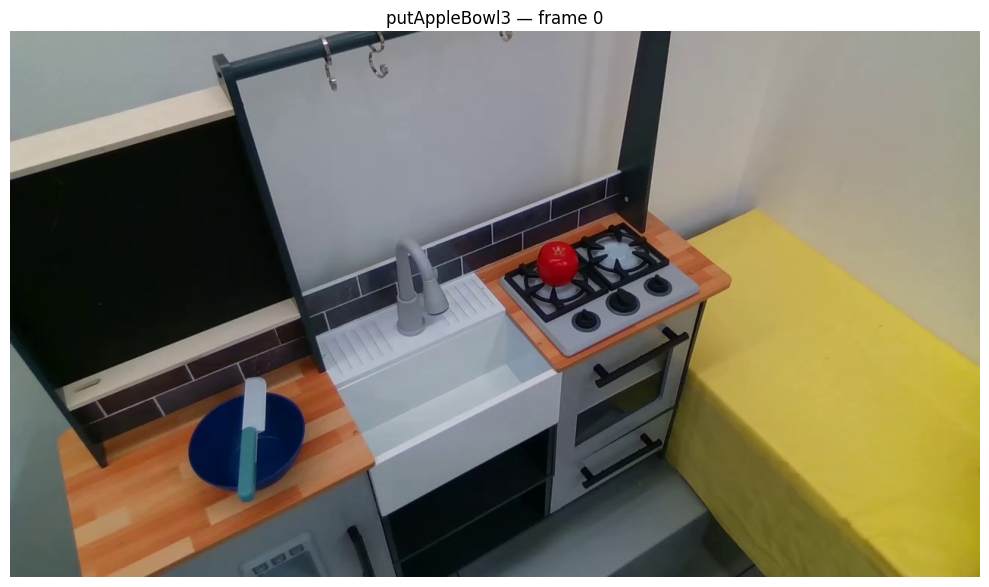

In [6]:
def extract_frame(video_path, frame_idx):
    """Extract a single RGB frame (H, W, 3) from an MP4 by frame index."""
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f"Failed to read frame {frame_idx} from {video_path}")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def extract_depth_frame(task_root, frame_idx):
    """Try to extract depth for a frame. Returns None if no depth source exists."""
    # Option 1: depth video
    depth_vid = task_root / "videos" / "depth.mp4"
    if depth_vid.exists():
        cap = cv2.VideoCapture(str(depth_vid))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        cap.release()
        if ret:
            return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32)

    # Option 2: depth as zarr array directory at videos/depth (contains .zarray + chunk files)
    depth_dir = task_root / "videos" / "depth"
    if depth_dir.exists() and (depth_dir / ".zarray").exists():
        try:
            depth_arr = zarr.open_array(str(depth_dir), mode="r")
            if frame_idx < depth_arr.shape[0]:
                depth = np.asarray(depth_arr[frame_idx])
                if depth.ndim == 3 and depth.shape[-1] in (3, 4):
                    depth = cv2.cvtColor(depth.astype(np.uint8), cv2.COLOR_BGR2GRAY)
                return depth.astype(np.float32)
        except Exception:
            # Some datasets use codecs unavailable in this environment; decode chunk file directly.
            from imagecodecs import imread as ic_imread
            for name in (f"{frame_idx}.0.0", f"{frame_idx}.0.0.0"):
                chunk_path = depth_dir / name
                if chunk_path.exists():
                    depth = ic_imread(str(chunk_path))
                    if depth.ndim == 3 and depth.shape[-1] in (3, 4):
                        depth = cv2.cvtColor(depth.astype(np.uint8), cv2.COLOR_BGR2GRAY)
                    return np.asarray(depth, dtype=np.float32)
            matches = list(depth_dir.rglob(f"{frame_idx}.0.0*"))
            if matches:
                depth = ic_imread(str(matches[0]))
                if depth.ndim == 3 and depth.shape[-1] in (3, 4):
                    depth = cv2.cvtColor(depth.astype(np.uint8), cv2.COLOR_BGR2GRAY)
                return np.asarray(depth, dtype=np.float32)

    # Option 3: depth in replay_buffer.zarr
    zarr_path = task_root / "replay_buffer.zarr"
    if zarr_path.exists():
        zr = zarr.open_group(str(zarr_path), mode="r")
        for key in ["data/depth", "depth", "data/depth_video"]:
            try:
                return np.array(zr[key][frame_idx])
            except (KeyError, IndexError):
                continue
    return None


def get_video_frame_count(video_path):
    cap = cv2.VideoCapture(str(video_path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return n


# Quick test
test_video = REAL_DATA_DIR / folder_name / "videos" / "color.mp4"
test_frame = extract_frame(test_video, 0)
print(f"Test frame shape: {test_frame.shape}, dtype: {test_frame.dtype}")

plt.figure(figsize=(10, 6))
plt.imshow(test_frame)
plt.title(f"{folder_name} — frame 0")
plt.axis("off")
plt.tight_layout()
plt.show()

### Load Pipeline Modules

Now that the symlinks and helpers are in place, we import the pipeline modules. The MDETR segmentation model is loaded onto the GPU (or CPU) at import time — this takes a moment on first run as it downloads the pretrained checkpoint.

In [7]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ.setdefault("MDETR_DET_THRESH", "0.90")

# Ensure REFLECT source package paths are importable from this notebook.
reflect_root = (Path.cwd().parent / "reflect-main").resolve()
reflect_main_pkg_root = reflect_root / "main"

for p in [reflect_root, reflect_main_pkg_root]:
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

from mdetr_object_detector import plot_inference_segmentation, seg_model
from real_world_scene_graph import Node as SceneGraphNode, SceneGraph
from real_world_get_local_sg import (
    get_scene_graph, obj_det, confirm_obj_det, edit_label,
    intrinsics_matrix
)
from real_world_hierarchical_prompt import get_scene_text
from real_world_utils import get_robot_plan
# from constants import BULKY_OBJECTS, real_world_name_map, real_world_obj_state_map

print(f"Added to sys.path: {reflect_root}")
print(f"Added to sys.path: {reflect_main_pkg_root}")
print("Pipeline modules loaded.")
print(f"MDETR seg_model on: {next(seg_model.parameters()).device}")
print(f"MDETR_DET_THRESH: {os.environ['MDETR_DET_THRESH']}")

/home/coder/workspace/reflect_UV/REFLECT_Group_Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1336.12it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1422.69it/s]
RobertaModel LOAD REPORT from: sentence-transformers/stsb-roberta-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1868.82it/s]
RobertaModel LOAD REPORT from: sentence-transformers/stsb-roberta-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Added to sys.path: /home/coder/workspace/reflect_UV/REFLECT_Group_Project/reflect-main
Added to sys.path: /home/coder/workspace/reflect_UV/REFLECT_Group_Project/reflect-main/main
Pipeline modules loaded.
MDETR seg_model on: cuda:0
MDETR_DET_THRESH: 0.90


### Optionally Load AudioCLIP

AudioCLIP is only needed when `USE_AUDIO = True`. Skipping it saves significant load time and avoids dependency issues if the AudioCLIP package isn't installed.

In [8]:
if USE_AUDIO:
    try:
        from AudioCLIP.real_world_audio import get_sound_events
        print("AudioCLIP loaded.")
    except ImportError:
        print("AudioCLIP not available — falling back to no audio.")
        USE_AUDIO = False
        args.audio_ver = 0
else:
    print("Audio disabled — skipping AudioCLIP import.")

Audio disabled — skipping AudioCLIP import.


### Initialize LLM Prompter

In [ ]:
# from LLM.prompt import LLMPrompter

# llm_prompter = LLMPrompter(gpt_version="gpt-4")
# print("LLM prompter ready.")

## Stage 1 — Extract Interaction Actions from Zarr

The `replay_buffer.zarr` stores per-frame `data/stage` labels that map to the action list in the task JSON. This cell reads the stage transitions to determine which frames correspond to interaction start/end points. These endpoints drive both key-frame selection and L2 summary generation.

In [9]:
def read_zarr_metadata(zarr_path):
    """Open a directory-backed zarr store in read-only mode."""
    return zarr.open_group(str(zarr_path), mode="r")


def get_stage_array(meta_data):
    """Return the stage array from common replay_buffer.zarr layouts."""
    candidate_keys = ["data/stage", "meta/stage", "stage"]
    for key in candidate_keys:
        try:
            return np.asarray(meta_data[key])
        except KeyError:
            continue
    available = list(meta_data.array_keys()) if hasattr(meta_data, "array_keys") else []
    raise KeyError(f"Could not find a stage array. Tried {candidate_keys}. Available arrays: {available}")


def get_interact_actions_from_zarr(stage_array, task_json):
    """Extract interaction action windows from zarr stage data."""
    total_frames = len(stage_array)
    stages = {}
    prev_stage = int(stage_array[0]) if total_frames > 0 else 0

    for step_idx in range(total_frames):
        curr_stage = int(stage_array[step_idx])
        if curr_stage not in stages:
            stages[curr_stage] = [step_idx]
        if curr_stage != prev_stage and prev_stage in stages and len(stages[prev_stage]) == 1:
            stages[prev_stage].append(step_idx - 1)
        prev_stage = curr_stage

    if total_frames > 0 and curr_stage in stages and len(stages[curr_stage]) == 1:
        stages[curr_stage].append(total_frames - 1)

    actions = task_json["actions"]
    interact_actions = {}
    for k, v in stages.items():
        if len(v) < 2:
            continue
        if k < len(actions) and actions[k] != "Terminate":
            interact_actions[(v[0], v[1])] = actions[k]

    return interact_actions


# Run for the first task
task_info = tasks_json[f"Task {task_list[0]}"]
folder_name = task_info["general_folder_name"]
task_root = REAL_DATA_DIR / folder_name

meta_data = read_zarr_metadata(task_root / "replay_buffer.zarr")
stage_array = get_stage_array(meta_data)
total_frames = len(stage_array)
video_path = task_root / "videos" / "color.mp4"
video_frames = get_video_frame_count(video_path)

print(f"Zarr frames (stages): {total_frames}")
print(f"Video frames:         {video_frames}")

interact_actions = get_interact_actions_from_zarr(stage_array, task_info)
print(f"\nInteraction actions:")
for (start, end), action in interact_actions.items():
    print(f"  [{start:>6d} - {end:>6d}]  {action}")

interact_end_idx = [idx[1] for idx in interact_actions if "Ignore" not in interact_actions[idx]]
print(f"\nKey endpoint frames: {interact_end_idx}")

Zarr frames (stages): 1986
Video frames:         1986

Interaction actions:
  [     0 -    933]  Pick up apple
  [   934 -   1985]  Put apple inside bowl

Key endpoint frames: [933, 1985]


### Stage 1b — Audio Event Detection (if enabled)

When `USE_AUDIO` is on, AudioCLIP scans the audio track for notable sound events (e.g., cracking, pouring) and maps them to frame indices. These frames become additional key-frame candidates.

In [10]:
sound_det_idx_dict = {}

if USE_AUDIO:
    audio_path = task_root / "videos" / "audio.wav"
    if audio_path.exists():
        volume_thresh = 0.03 if task_info.get("task_idx") == 3 else 0.04
        detected_sounds = get_sound_events(audio_path=str(audio_path), volume_thresh=volume_thresh)
        for sound_range, description in detected_sounds.items():
            frame_idx = int(sound_range[1] * 30)
            sound_det_idx_dict[frame_idx] = description
        print(f"Detected {len(sound_det_idx_dict)} audio event(s): {sound_det_idx_dict}")
    else:
        print(f"No audio file at {audio_path}")
else:
    print("Audio disabled — no sound events.")

Audio disabled — no sound events.


## Stage 2 — Object Detection + Scene Graph Construction (L0)

This is the core loop. For each interaction endpoint frame (plus any audio event frames), we:
1. Extract the RGB frame from the MP4 video
2. Run MDETR segmentation for each object in the task's object list
3. Confirm detections with CLIP similarity scoring
4. If depth is available: build a 3D point cloud per object, compute 3D bounding boxes, and derive spatial edges (on top of, inside, near, etc.)
5. If depth is not available: build a 2D-only scene graph with object states but without 3D spatial edges
6. Track key frames where the scene graph changes

All local scene graphs and detections are cached to disk so later stages don't re-run detection.

In [11]:
args.folder_name = folder_name
raw_object_list = task_info["object_list"]
distractor_list = task_info.get("distractor_list", [])

# Process every Nth frame in the video, but always include action endpoint frames.
FRAME_STRIDE = 30

# MDETR is sensitive to over-specific noun phrases (e.g., "without object on top").
# Use cleaner prompts while preserving intended object identity.
def normalize_prompt(p):
    p = p.strip()
    p = p.replace(" without object on top", "")
    p = p.replace(" with object on top", "")
    p = p.replace(" on the left of sink", "")
    return p

object_list = [normalize_prompt(p) for p in raw_object_list]

# Create output directories
summary_dir = rw_root / "state_summary" / folder_name
summary_dir.mkdir(parents=True, exist_ok=True)
(summary_dir / "local_graphs").mkdir(exist_ok=True)
(summary_dir / f"{OBJ_DETECTOR}_obj_det" / "det").mkdir(parents=True, exist_ok=True)
(summary_dir / f"{OBJ_DETECTOR}_obj_det" / "clip_processed_det").mkdir(parents=True, exist_ok=True)
(summary_dir / f"{OBJ_DETECTOR}_obj_det" / "images").mkdir(parents=True, exist_ok=True)
(rw_root / "scene" / folder_name).mkdir(parents=True, exist_ok=True)

frames_to_process = sorted({*range(0, video_frames, FRAME_STRIDE), *interact_end_idx})

print(f"Raw objects:        {raw_object_list}")
print(f"Detection prompts:  {object_list}")
print(f"Frame stride:       {FRAME_STRIDE}")
print(f"Key endpoints:      {interact_end_idx}")
print(f"Frames to process:  {len(frames_to_process)}")
print(f"Frame indices:      {frames_to_process[:20]}{' ...' if len(frames_to_process) > 20 else ''}")

Raw objects:        ['knife with blue handle', 'red apple', 'dark blue bowl']
Detection prompts:  ['knife with blue handle', 'red apple', 'dark blue bowl']
Frame stride:       30
Key endpoints:      [933, 1985]
Frames to process:  69
Frame indices:      [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450, 480, 510, 540, 570] ...


In [12]:
total_points_dict, bbox3d_dict, bbox2d_dict = {}, {}, {}
prev_graph = SceneGraph()
key_frames = []
local_graphs = {}

for i, step_idx in enumerate(frames_to_process):
    print(f"\n[{i+1}/{len(frames_to_process)}] Frame {step_idx}")

    rgb = extract_frame(video_path, step_idx)
    depth = extract_depth_frame(task_root, step_idx)

    if depth is not None:
        # Full 3D pipeline via get_scene_graph
        local_sg, bbox3d_dict, total_points_dict, bbox2d_dict = get_scene_graph(
            args, rgb, depth, step_idx, object_list, distractor_list,
            seg_model, total_points_dict, bbox3d_dict, meta_data, task_info
        )
    else:
        # 2D-only fallback: run detection, build graph without 3D edges
        im = Image.fromarray(rgb)
        local_sg = SceneGraph()

        all_outputs = {
            "total_detections": 0, "labels": np.array([]),
            "scores": np.array([]), "pred_masks": np.array([]),
            "bbox_2d": np.array([])
        }

        for obj_prompt in object_list:
            retval = plot_inference_segmentation(im, obj_prompt, seg_model)
            if len(all_outputs["pred_masks"]) == 0:
                all_outputs["pred_masks"] = retval["masks"]
                all_outputs["bbox_2d"] = retval["bbox_2d"]
            else:
                if len(retval["masks"]) > 0:
                    all_outputs["pred_masks"] = np.concatenate((all_outputs["pred_masks"], retval["masks"]))
                    all_outputs["bbox_2d"] = np.concatenate((all_outputs["bbox_2d"], retval["bbox_2d"]))
            all_outputs["scores"] = np.concatenate((all_outputs["scores"], retval["probs"]))
            all_outputs["labels"] = np.concatenate((all_outputs["labels"], retval["labels"]))

        all_outputs["total_detections"] = len(all_outputs["scores"])

        if all_outputs["total_detections"] > 0:
            all_outputs = confirm_obj_det(args, rgb, all_outputs, object_list, step_idx)
            all_outputs["labels"] = edit_label(all_outputs["labels"])

            for idx in range(all_outputs["total_detections"]):
                label = all_outputs["labels"][idx]
                if label.split("-")[0] in distractor_list:
                    continue
                node = SceneGraphNode(
                    name=label, object_id=label,
                    pos3d=np.zeros(3), corner_pts=np.zeros((8, 3)),
                    bbox2d=all_outputs["bbox_2d"][idx],
                    pcd=np.zeros((1, 3)),
                )
                local_sg.add_node_wo_edge(node)
                local_sg.add_node(node, rgb)

    # Cache the local scene graph
    sg_path = summary_dir / "local_graphs" / f"local_sg_{step_idx}.pkl"
    with open(sg_path, "wb") as f:
        pickle.dump(local_sg, f)
    local_graphs[step_idx] = local_sg

    # Track key frames (scene graph changed)
    if local_sg != prev_graph:
        if step_idx not in key_frames:
            key_frames.append(step_idx)
        prev_graph = local_sg

    # Audio events are also key frames
    if step_idx in sound_det_idx_dict and step_idx not in key_frames:
        key_frames.append(step_idx)

    print(f"  Nodes: {[n.get_name() for n in local_sg.nodes]}")
    print(f"  Edges: {[str(e) for e in local_sg.edges.values() if e.edge_type != 'none']}")

# Always include interaction endpoints (and audio events) even if scene graph is unchanged.
key_frames = sorted(set(key_frames) | set(interact_end_idx) | set(sound_det_idx_dict.keys()))
print(f"\nKey frames selected: {key_frames}")


[1/69] Frame 0
object detection using mdetr
probas:  (100,)
probas:  (100,)
probas:  (100,)
total_detections:  15
outputs before:  ['knife with blue handle' 'knife with blue handle' 'red apple' 'red apple'
 'red apple' 'dark blue bowl' 'red apple' 'dark blue bowl'
 'dark blue bowl' 'red apple' 'knife with blue handle'
 'knife with blue handle' 'dark blue bowl' 'dark blue bowl'
 'dark blue bowl']
outputs before:  [0.90778339 0.90920544 0.9158873  0.91596001 0.91830057 0.92587757
 0.92914551 0.93105119 0.93655282 0.9478845  0.95052195 0.95061445
 0.95404196 0.96342903 0.97393268]
outputs before:  (15, 720, 1280)
outputs before:  (15, 4)
outputs before:  15
Confirming for:  knife with blue handle 0.9077833890914917
sorted_obj_names:  ['red apple', 'dark blue bowl', 'knife with blue handle']
sorted_scores:  [0.250624   0.22249278 0.21485114]
Confirming for:  knife with blue handle 0.909205436706543
sorted_obj_names:  ['red apple', 'dark blue bowl', 'knife with blue handle']
sorted_scores:

In [17]:
# Lightweight runtime profiler for Stage 2 bottlenecks
import time
from collections import defaultdict
import statistics as stats

PROFILE_MAX_FRAMES = 3  # keep small; increase for more stable numbers
sample_frames = frames_to_process[:PROFILE_MAX_FRAMES]

print(f"Profiling {len(sample_frames)} frame(s): {sample_frames}")

breakdown = defaultdict(list)

for j, step_idx in enumerate(sample_frames, 1):
    print(f"\n[Profile {j}/{len(sample_frames)}] frame={step_idx}")

    t0 = time.perf_counter()
    rgb = extract_frame(video_path, step_idx)
    breakdown["extract_rgb"].append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    depth = extract_depth_frame(task_root, step_idx)
    breakdown["extract_depth"].append(time.perf_counter() - t0)

    if depth is not None:
        t0 = time.perf_counter()
        _local_sg, _bbox3d_tmp, _points_tmp, _bbox2d_tmp = get_scene_graph(
            args,
            rgb,
            depth,
            step_idx,
            object_list,
            distractor_list,
            seg_model,
            total_points_dict.copy(),
            bbox3d_dict.copy(),
            meta_data,
            task_info,
        )
        breakdown["get_scene_graph_total"].append(time.perf_counter() - t0)
    else:
        im = Image.fromarray(rgb)
        all_outputs = {
            "total_detections": 0,
            "labels": np.array([]),
            "scores": np.array([]),
            "pred_masks": np.array([]),
            "bbox_2d": np.array([]),
        }

        t0 = time.perf_counter()
        for obj_prompt in object_list:
            t_obj = time.perf_counter()
            retval = plot_inference_segmentation(im, obj_prompt, seg_model)
            breakdown["mdetr_per_prompt"].append(time.perf_counter() - t_obj)

            if len(all_outputs["pred_masks"]) == 0:
                all_outputs["pred_masks"] = retval["masks"]
                all_outputs["bbox_2d"] = retval["bbox_2d"]
            else:
                if len(retval["masks"]) > 0:
                    all_outputs["pred_masks"] = np.concatenate((all_outputs["pred_masks"], retval["masks"]))
                    all_outputs["bbox_2d"] = np.concatenate((all_outputs["bbox_2d"], retval["bbox_2d"]))
            all_outputs["scores"] = np.concatenate((all_outputs["scores"], retval["probs"]))
            all_outputs["labels"] = np.concatenate((all_outputs["labels"], retval["labels"]))

        breakdown["mdetr_all_prompts_total"].append(time.perf_counter() - t0)

        all_outputs["total_detections"] = len(all_outputs["scores"])

        if all_outputs["total_detections"] > 0:
            t0 = time.perf_counter()
            _confirmed = confirm_obj_det(args, rgb, all_outputs, object_list, step_idx)
            breakdown["clip_confirm_total"].append(time.perf_counter() - t0)

print("\n=== Runtime Breakdown (seconds) ===")
rows = []
for k, vals in breakdown.items():
    if not vals:
        continue
    rows.append((k, len(vals), sum(vals), stats.mean(vals), max(vals)))

rows = sorted(rows, key=lambda x: x[2], reverse=True)
for name, n, total_s, mean_s, max_s in rows:
    print(f"{name:24s} n={n:2d} total={total_s:8.3f}s mean={mean_s:7.3f}s max={max_s:7.3f}s")

if "mdetr_all_prompts_total" in breakdown and len(object_list) > 0:
    est_per_frame = stats.mean(breakdown["mdetr_all_prompts_total"])
    est_full = est_per_frame * len(frames_to_process)
    print(f"\nEstimated MDETR-only time over all {len(frames_to_process)} frames: ~{est_full/60:.1f} min")

Profiling 3 frame(s): [0, 30, 60]

[Profile 1/3] frame=0
object detection using mdetr
probas:  (100,)
probas:  (100,)
probas:  (100,)
total_detections:  15
outputs before:  ['knife with blue handle' 'knife with blue handle' 'red apple' 'red apple'
 'red apple' 'dark blue bowl' 'red apple' 'dark blue bowl'
 'dark blue bowl' 'red apple' 'knife with blue handle'
 'knife with blue handle' 'dark blue bowl' 'dark blue bowl'
 'dark blue bowl']
outputs before:  [0.90778339 0.90920544 0.9158873  0.91596001 0.91830057 0.92587757
 0.92914551 0.93105119 0.93655282 0.9478845  0.95052195 0.95061445
 0.95404196 0.96342903 0.97393268]
outputs before:  (15, 720, 1280)
outputs before:  (15, 4)
outputs before:  15
Confirming for:  knife with blue handle 0.9077833890914917
sorted_obj_names:  ['red apple', 'dark blue bowl', 'knife with blue handle']
sorted_scores:  [0.250624   0.22249278 0.21485114]
Confirming for:  knife with blue handle 0.909205436706543
sorted_obj_names:  ['red apple', 'dark blue bowl',

In [18]:
# Quiet profiler: suppress verbose model logs and print only timing summary
import io
import time
import contextlib
from collections import defaultdict
import statistics as stats

PROFILE_MAX_FRAMES = 2
sample_frames = frames_to_process[:PROFILE_MAX_FRAMES]

breakdown = defaultdict(list)
null_out = io.StringIO()

for step_idx in sample_frames:
    t0 = time.perf_counter()
    rgb = extract_frame(video_path, step_idx)
    breakdown["extract_rgb"].append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    depth = extract_depth_frame(task_root, step_idx)
    breakdown["extract_depth"].append(time.perf_counter() - t0)

    if depth is not None:
        t0 = time.perf_counter()
        with contextlib.redirect_stdout(null_out):
            _ = get_scene_graph(
                args,
                rgb,
                depth,
                step_idx,
                object_list,
                distractor_list,
                seg_model,
                total_points_dict.copy(),
                bbox3d_dict.copy(),
                meta_data,
                task_info,
            )
        breakdown["get_scene_graph_total"].append(time.perf_counter() - t0)
    else:
        im = Image.fromarray(rgb)
        all_outputs = {
            "total_detections": 0,
            "labels": np.array([]),
            "scores": np.array([]),
            "pred_masks": np.array([]),
            "bbox_2d": np.array([]),
        }

        t0 = time.perf_counter()
        for obj_prompt in object_list:
            t_obj = time.perf_counter()
            with contextlib.redirect_stdout(null_out):
                retval = plot_inference_segmentation(im, obj_prompt, seg_model)
            breakdown["mdetr_per_prompt"].append(time.perf_counter() - t_obj)

            if len(all_outputs["pred_masks"]) == 0:
                all_outputs["pred_masks"] = retval["masks"]
                all_outputs["bbox_2d"] = retval["bbox_2d"]
            else:
                if len(retval["masks"]) > 0:
                    all_outputs["pred_masks"] = np.concatenate((all_outputs["pred_masks"], retval["masks"]))
                    all_outputs["bbox_2d"] = np.concatenate((all_outputs["bbox_2d"], retval["bbox_2d"]))
            all_outputs["scores"] = np.concatenate((all_outputs["scores"], retval["probs"]))
            all_outputs["labels"] = np.concatenate((all_outputs["labels"], retval["labels"]))

        breakdown["mdetr_all_prompts_total"].append(time.perf_counter() - t0)

        all_outputs["total_detections"] = len(all_outputs["scores"])
        if all_outputs["total_detections"] > 0:
            t0 = time.perf_counter()
            with contextlib.redirect_stdout(null_out):
                _confirmed = confirm_obj_det(args, rgb, all_outputs, object_list, step_idx)
            breakdown["clip_confirm_total"].append(time.perf_counter() - t0)

print(f"Profiled frames: {sample_frames}")
rows = []
for k, vals in breakdown.items():
    rows.append((k, len(vals), sum(vals), stats.mean(vals), max(vals)))
rows.sort(key=lambda x: x[2], reverse=True)
for name, n, total_s, mean_s, max_s in rows:
    print(f"{name:24s} n={n:2d} total={total_s:7.3f}s mean={mean_s:7.3f}s max={max_s:7.3f}s")

if "mdetr_all_prompts_total" in breakdown:
    est_per_frame = stats.mean(breakdown["mdetr_all_prompts_total"])
    print(f"Estimated MDETR-only per frame: {est_per_frame:.3f}s")
    print(f"Estimated MDETR-only for {len(frames_to_process)} frames: {(est_per_frame * len(frames_to_process))/60:.1f} min")

Profiled frames: [0, 30]
get_scene_graph_total    n= 2 total= 74.502s mean= 37.251s max= 54.774s
extract_rgb              n= 2 total=  0.068s mean=  0.034s max=  0.037s
extract_depth            n= 2 total=  0.046s mean=  0.023s max=  0.024s


In [19]:
# Deep profile for one frame: break get_scene_graph into major phases
import io
import time
import contextlib
import numpy as np
import real_world_get_local_sg as rwsg

step_idx = sample_frames[0] if "sample_frames" in globals() else frames_to_process[0]
rgb = extract_frame(video_path, step_idx)
depth = extract_depth_frame(task_root, step_idx)
assert depth is not None, "This deep profile assumes depth is available."

null_out = io.StringIO()
prof = {}

# 1) Object detection
st = time.perf_counter()
with contextlib.redirect_stdout(null_out):
    outputs = rwsg.obj_det(rgb, object_list, seg_model, step_idx, args)
prof["obj_det_total"] = time.perf_counter() - st

# 2) CLIP confirmation
if outputs["total_detections"] > 0:
    st = time.perf_counter()
    with contextlib.redirect_stdout(null_out):
        outputs = rwsg.confirm_obj_det(args, rgb, outputs, object_list, step_idx)
    prof["confirm_obj_det_total"] = time.perf_counter() - st

    st = time.perf_counter()
    _ = rwsg.edit_label(outputs["labels"])
    prof["edit_label"] = time.perf_counter() - st

# 3) 3D conversion + bbox per detection
pcd_times = []
if outputs["total_detections"] > 0:
    for idx in range(outputs["total_detections"]):
        label = outputs["labels"][idx]
        if label.split("-")[0] in distractor_list or outputs["scores"][idx] < 0:
            continue

        st = time.perf_counter()
        masked_depth = depth * outputs["pred_masks"][idx]
        point_3d = rwsg.depth_to_point_cloud(rwsg.intrinsics_matrix, masked_depth)

        obj_pcd = rwsg.o3d.geometry.PointCloud()
        obj_pcd.points = rwsg.o3d.utility.Vector3dVector(point_3d)
        voxel_down_pcd = obj_pcd.voxel_down_sample(voxel_size=0.01)
        _, ind = voxel_down_pcd.remove_statistical_outlier(nb_neighbors=1500, std_ratio=0.1)
        inlier = voxel_down_pcd.select_by_index(ind)

        pts = np.array(inlier.points)
        box_pts = rwsg.o3d.utility.Vector3dVector(pts)
        _box = rwsg.o3d.geometry.AxisAlignedBoundingBox.create_from_points(box_pts)
        pcd_times.append(time.perf_counter() - st)

prof["pcd_bbox_per_det_mean"] = float(np.mean(pcd_times)) if pcd_times else 0.0
prof["pcd_bbox_total"] = float(np.sum(pcd_times)) if pcd_times else 0.0
prof["pcd_bbox_num_det"] = len(pcd_times)

print(f"Deep profile frame: {step_idx}")
for k in ["obj_det_total", "confirm_obj_det_total", "edit_label", "pcd_bbox_total", "pcd_bbox_per_det_mean", "pcd_bbox_num_det"]:
    if k in prof:
        v = prof[k]
        if isinstance(v, float):
            print(f"{k:24s}: {v:8.3f}s")
        else:
            print(f"{k:24s}: {v}")

mdetr labels: ['red apple']
real world labels: ['apple']
Deep profile frame: 0
obj_det_total           :    3.826s
confirm_obj_det_total   :    0.551s
edit_label              :    0.000s
pcd_bbox_total          :    1.550s
pcd_bbox_per_det_mean   :    1.550s
pcd_bbox_num_det        : 1


In [ ]:
# Deep profile on another sampled frame (often heavier)
import io
import time
import contextlib
import numpy as np
import real_world_get_local_sg as rwsg

step_idx = sample_frames[-1] if "sample_frames" in globals() else frames_to_process[min(1, len(frames_to_process)-1)]
rgb = extract_frame(video_path, step_idx)
depth = extract_depth_frame(task_root, step_idx)
assert depth is not None, "This deep profile assumes depth is available."

null_out = io.StringIO()
prof = {}

st = time.perf_counter()
with contextlib.redirect_stdout(null_out):
    outputs = rwsg.obj_det(rgb, object_list, seg_model, step_idx, args)
prof["obj_det_total"] = time.perf_counter() - st

if outputs["total_detections"] > 0:
    st = time.perf_counter()
    with contextlib.redirect_stdout(null_out):
        outputs = rwsg.confirm_obj_det(args, rgb, outputs, object_list, step_idx)
    prof["confirm_obj_det_total"] = time.perf_counter() - st

    st = time.perf_counter()
    outputs["labels"] = rwsg.edit_label(outputs["labels"])
    prof["edit_label"] = time.perf_counter() - st

pcd_times = []
if outputs["total_detections"] > 0:
    for idx in range(outputs["total_detections"]):
        label = outputs["labels"][idx]
        if label.split("-")[0] in distractor_list or outputs["scores"][idx] < 0:
            continue

        st = time.perf_counter()
        masked_depth = depth * outputs["pred_masks"][idx]
        point_3d = rwsg.depth_to_point_cloud(rwsg.intrinsics_matrix, masked_depth)
        obj_pcd = rwsg.o3d.geometry.PointCloud()
        obj_pcd.points = rwsg.o3d.utility.Vector3dVector(point_3d)
        voxel_down_pcd = obj_pcd.voxel_down_sample(voxel_size=0.01)
        _, ind = voxel_down_pcd.remove_statistical_outlier(nb_neighbors=1500, std_ratio=0.1)
        inlier = voxel_down_pcd.select_by_index(ind)
        pts = np.array(inlier.points)
        if len(pts) > 0:
            box_pts = rwsg.o3d.utility.Vector3dVector(pts)
            _box = rwsg.o3d.geometry.AxisAlignedBoundingBox.create_from_points(box_pts)
        pcd_times.append(time.perf_counter() - st)

prof["pcd_bbox_total"] = float(np.sum(pcd_times)) if pcd_times else 0.0
prof["pcd_bbox_per_det_mean"] = float(np.mean(pcd_times)) if pcd_times else 0.0
prof["pcd_bbox_num_det"] = len(pcd_times)

print(f"Deep profile frame: {step_idx}")
for k in ["obj_det_total", "confirm_obj_det_total", "edit_label", "pcd_bbox_total", "pcd_bbox_per_det_mean", "pcd_bbox_num_det"]:
    if k in prof:
        v = prof[k]
        if isinstance(v, float):
            print(f"{k:24s}: {v:8.3f}s")
        else:
            print(f"{k:24s}: {v}")

### Build Global Scene Graph

The global graph aggregates all detected objects across frames into a single scene graph representing the full workspace layout. With depth it merges 3D point clouds; without depth it uses the last-seen 2D detections.

In [13]:
global_sg = SceneGraph()

if total_points_dict:  # 3D data available
    # replay_buffer can have one more step than color.mp4; clamp to valid video frame index
    last_valid_idx = min(frames_to_process[-1], video_frames - 1)
    if last_valid_idx != frames_to_process[-1]:
        print(f"Clamping last frame index {frames_to_process[-1]} -> {last_valid_idx} (video_frames={video_frames})")
    last_rgb = extract_frame(video_path, last_valid_idx)
    for label in total_points_dict:
        if label in bbox3d_dict and label in bbox2d_dict:
            node = SceneGraphNode(
                name=label, object_id=label,
                pos3d=bbox3d_dict[label].get_center(),
                corner_pts=np.array(bbox3d_dict[label].get_box_points()),
                bbox2d=bbox2d_dict[label],
                pcd=total_points_dict[label],
                global_node=True
            )
            global_sg.add_node_wo_edge(node)
            global_sg.add_node(node, last_rgb)
else:
    # 2D fallback: merge unique nodes from all local graphs
    seen_names = set()
    for sg in local_graphs.values():
        for node in sg.nodes:
            if node.name not in seen_names:
                global_sg.add_node_wo_edge(node)
                global_sg.nodes.append(node)
                seen_names.add(node.name)

with open(summary_dir / "global_sg.pkl", "wb") as f:
    pickle.dump(global_sg, f)

print("Global scene graph:")
print(global_sg)

Global scene graph:
[Nodes]:
apple
dark blue bowl

[Edges]:
apple->inside->dark blue bowl



### Save Key Frames

In [14]:
kf_path = summary_dir / "L1_key_frames.txt"
with open(kf_path, "w") as f:
    for frame in key_frames:
        f.write(f"{frame}\n")
print(f"Saved {len(key_frames)} key frames to {kf_path}")

Saved 48 key frames to /home/coder/workspace/reflect_UV/REFLECT_Group_Project/real-world-code/real_world/state_summary/putAppleBowl3/L1_key_frames.txt


## Stage 3 — Generate Hierarchical Summaries

### L1 Summary (key-frame level)

For each key frame, an L1 caption combines the timestamp, action label, visual observation (scene graph as text), and optionally an auditory observation. These are the foundation for LLM reasoning.

In [15]:
def convert_step_to_timestep(step, video_fps=30):
    """Convert a frame index to a MM:SS timestamp string."""
    seconds = step / video_fps
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes:02d}:{secs:02d}"


L1_captions = []

for step_idx in key_frames:
    if step_idx == 0:
        continue

    caption = ""

    # Find the action window this frame belongs to
    for (start, end), action in interact_actions.items():
        if start <= step_idx <= end:
            ts = convert_step_to_timestep(step_idx)
            caption += f"{ts}. Action: {action}."
            break

    if not caption or "Ignore" in caption or "Skip" in caption:
        continue

    # Visual observation from scene graph
    if step_idx in local_graphs:
        scene_text = get_scene_text(local_graphs[step_idx])
        if scene_text:
            caption += f" Visual observation: {scene_text}"

    # Audio observation (if enabled)
    if step_idx in sound_det_idx_dict:
        caption += f" Auditory observation: {sound_det_idx_dict[step_idx]}."

    caption += "\n"

    # Skip duplicate timestamps
    if L1_captions and caption.split(".")[0] == L1_captions[-1].split(".")[0]:
        continue

    L1_captions.append(caption)
    print(caption.strip())

# Save
suffix = "_wo_sound" if not USE_AUDIO else ""
l1_path = summary_dir / f"state_summary_L1{suffix}.txt"
with open(l1_path, "w") as f:
    f.writelines(L1_captions)
print(f"\nSaved L1 summary ({len(L1_captions)} captions) to {l1_path}")

00:01. Action: Pick up apple. Visual observation: apple-1, apple-2, dark blue bowl. apple-2 is inside apple-1. apple-1 is on the left of apple-2. apple-1 is inside dark blue bowl. apple-2 is inside dark blue bowl. dark blue bowl is inside robot gripper.
00:02. Action: Pick up apple. Visual observation: apple-1, apple-2. apple-2 is inside apple-1. nothing is inside robot gripper.
00:03. Action: Pick up apple. Visual observation: apple. nothing is inside robot gripper.
00:04. Action: Pick up apple. Visual observation: apple, dark blue bowl. apple is inside dark blue bowl. dark blue bowl is inside robot gripper.
00:06. Action: Pick up apple. Visual observation: apple. dark blue bowl is inside robot gripper.
00:07. Action: Pick up apple. Visual observation: apple-1, apple-2. apple-1 is inside apple-2. nothing is inside robot gripper.
00:08. Action: Pick up apple. Visual observation: apple, dark blue bowl. apple is inside dark blue bowl. dark blue bowl is inside robot gripper.
00:09. Action

### L2 Summary (subgoal level)

The L2 summary filters L1 captions down to only the interaction endpoint frames, replacing "Action" with "Goal" to reflect the subgoal abstraction. This coarser summary is what the LLM first evaluates for pass/fail.

In [16]:
L2_captions = []

for end_idx in interact_end_idx:
    ts = convert_step_to_timestep(end_idx)
    for caption in L1_captions:
        if ts in caption:
            L2_captions.append(caption.replace("Action", "Goal"))
            break

l2_path = summary_dir / f"state_summary_L2{suffix}.txt"
with open(l2_path, "w") as f:
    f.writelines(L2_captions)

print(f"L2 Summary ({len(L2_captions)} subgoal captions):")
for cap in L2_captions:
    print(f"  {cap.strip()}")

L2 Summary (2 subgoal captions):
  00:31. Goal: Pick up apple. Visual observation: knife, dark blue bowl. dark blue bowl is inside knife. knife is on the right of dark blue bowl. knife is inside robot gripper.
  01:06. Goal: Put apple inside bowl. Visual observation: apple, dark blue bowl. apple is inside dark blue bowl. dark blue bowl is inside robot gripper.


## Stage 4 — LLM Failure Reasoning

The final stage sends the summaries to GPT-4 through a hierarchical prompt chain:
1. **Action-level check** — for each L2 subgoal, ask whether the action succeeded based on the visual observation
2. **Detailed reasoning** — if a failure is found, zoom into L1 captions around that step for an explanation
3. **Plan-level analysis** — if all actions passed, check the overall plan against the success condition

This requires `LLM/prompts-gpt4.json` with the prompt templates. If it doesn't exist, a standalone fallback prompt is used.

In [ ]:
prompt_file = Path("LLM/prompts-gpt4.json")

if prompt_file.exists():
    print("Using full hierarchical prompting from prompts-gpt4.json")
    from real_world_hierarchical_prompt import run_reasoning
    run_reasoning(args=args, task=task_info, global_sg=global_sg)

else:
    print("prompts-gpt4.json not found — running standalone reasoning prompt")
    print("(Create LLM/prompts-gpt4.json with the REFLECT prompt templates for the full chain)\n")

    l2_text = "".join(L2_captions)
    l1_text = "".join(L1_captions)

    standalone_prompt = {
        "system": (
            "You are an expert robot task analyst. Given a sequence of observations "
            "from a robot performing a task, identify if and where the task failed, "
            "and explain why."
        ),
        "user": (
            f"Task: {task_info['name']}\n"
            f"Success condition: {task_info['success_condition']}\n\n"
            f"High-level plan:\n{l2_text}\n\n"
            f"Detailed observations:\n{l1_text}\n\n"
            f"Did the robot succeed? If not, at which step did it fail and why?"
        )
    }

    print("--- Prompt (user) ---")
    print(standalone_prompt["user"][:1500])
    if len(standalone_prompt["user"]) > 1500:
        print("...")

    answer, _ = llm_prompter.query(
        prompt=standalone_prompt,
        sampling_params={"temperature": 0, "max_tokens": 500},
        save=False, save_dir=f"LLM/{folder_name}"
    )
    print(f"\n--- LLM Response ---")
    print(answer)

### Inspect Reasoning Results

In [ ]:
reasoning_names = [
    "reasoning.json", "reasoning-wo-sound.json",
    "reasoning-only-L2.json", "reasoning-BLIP2.json",
    "reasoning-BLIP2-direct.json", "llm-direct-reasoning.json",
    "reasoning-wo-framework.json",
]

found = False
for name in reasoning_names:
    path = summary_dir / name
    if path.exists():
        with open(path) as f:
            reasoning = json.load(f)
        print(f"\n--- {name} ---")
        print(f"Predicted failure reason: {reasoning.get('pred_failure_reason', 'N/A')}")
        print(f"Predicted failure step:   {reasoning.get('pred_failure_step', 'N/A')}")
        print(f"Ground-truth reason:      {reasoning.get('gt_failure_reason', 'N/A')}")
        print(f"Ground-truth step:        {reasoning.get('gt_failure_step', 'N/A')}")
        found = True

if not found:
    print("No reasoning output file found yet.")
    print(f"Ground-truth: {task_info['gt_failure_reason']}")
    print(f"GT step:      {task_info['gt_failure_step']}")

### Visualize Detections on Sample Frames

A quick sanity check: pull a few key frames from the video, show MDETR detections overlaid, and print the scene graph text. Useful for spotting detection failures before trusting the summaries.

In [ ]:
n_show = min(4, len(key_frames))
show_frames = key_frames[:n_show]

fig, axes = plt.subplots(1, n_show, figsize=(6 * n_show, 5))
if n_show == 1:
    axes = [axes]

for ax, step_idx in zip(axes, show_frames):
    rgb = extract_frame(video_path, step_idx)
    im = Image.fromarray(rgb)

    for obj_prompt in task_info["object_list"]:
        retval = plot_inference_segmentation(im, obj_prompt, seg_model)
        im = retval["im"]

    ax.imshow(im)
    ax.set_title(f"Frame {step_idx} ({convert_step_to_timestep(step_idx)})", fontsize=10)
    ax.axis("off")

plt.suptitle(f"{task_info['name']} - MDETR detections", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusion and Reflection

This notebook runs the REFLECT pipeline from raw MP4 video + zarr metadata through to GPT-4 failure reasoning, with a clean `USE_AUDIO` toggle for the with/without-sound ablation. The main adaptation from the original codebase was bridging the data format: the scripts expect zarr-stored individual frame chunks, but our data has `color.mp4` videos — handled here by extracting frames on-the-fly with OpenCV, plus symlinks for the rest of the path structure.

The depth situation is worth watching. The original pipeline heavily depends on RGB-D for 3D point clouds, bounding boxes, and spatial edge computation (on top of, inside, near). Without depth, the scene graph degrades to a flat list of detected objects with states but no spatial relations — the LLM still gets useful information, but misses things like "apple is on top of bowl" vs. "apple is inside bowl" which can be critical for failure diagnosis.

The most brittle part remains the detection thresholds. The MDETR confidence cutoff (0.96) and CLIP confirmation threshold (0.23) were tuned to specific tasks in the original codebase, with comments like "change from 0.25 to 0.23 for sauteeCarrot4". Running on new tasks will almost certainly require threshold adjustments, or ideally a more adaptive filtering approach.